# FK Steered diffusion in Flax

## 1. Setup packages

Install required libraries

In [1]:
!pip install --upgrade pip
!pip install ipywidgets
!pip install image-reward
!pip install "clip @ git+https://github.com/openai/CLIP.git"
!pip install jax flax optax transformers accelerate
!pip install --upgrade diffusers --pre
!pip install ipywidgets
!pip uninstall tensorflow -y
!pip install hpsv2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 9.2 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 17.7 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 17.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 18.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 19.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 22.4 MB/s eta 0:00:00
 

Import used classes

In [2]:
import warnings
from functools import partial
from typing import Any, Callable, Dict, List, NamedTuple, Optional, Tuple, Union
from enum import Enum

import numpy as np
import jax
import jax.numpy as jnp
from jax import pmap

from flax.core.frozen_dict import FrozenDict
from flax.jax_utils import replicate, unreplicate
from flax.training.common_utils import shard
import flax.linen as nn

from packaging import version
from PIL import Image

from transformers import CLIPImageProcessor
from transformers import CLIPTokenizer, CLIPTokenizerFast
from transformers import FlaxCLIPTextModel, FlaxCLIPModel

from diffusers.utils import (
    deprecate, 
    logging, 
    replace_example_docstring,
)
from diffusers import (
    FlaxAutoencoderKL, 
    FlaxUNet2DConditionModel,
    FlaxDDIMScheduler,
    FlaxDPMSolverMultistepScheduler,
    FlaxLMSDiscreteScheduler,
    FlaxPNDMScheduler,
    FlaxDiffusionPipeline
)
from diffusers.pipelines.stable_diffusion import (
    FlaxStableDiffusionPipelineOutput,
    FlaxStableDiffusionSafetyChecker
)

# Getting the hps model
!wget https://openaipublic.blob.core.windows.net/clip/bpe_simple_vocab_16e6.txt.gz -O bpe_simple_vocab_16e6.txt.gz

# For running on Kaggle
# Move it to the expected package location
!cp bpe_simple_vocab_16e6.txt.gz /usr/local/lib/python3.10/site-packages/hpsv2/src/open_clip/bpe_simple_vocab_16e6.txt.gz

import hpsv2

--2025-06-10 16:03:53--  https://openaipublic.blob.core.windows.net/clip/bpe_simple_vocab_16e6.txt.gz
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 57.150.104.161
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|57.150.104.161|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1356917 (1.3M) [application/octet-stream]
Saving to: ‘bpe_simple_vocab_16e6.txt.gz’

bpe_simple_vocab_16 100%[===================>]   1.29M  1.21MB/s    in 1.1s    

2025-06-10 16:03:55 (1.21 MB/s) - ‘bpe_simple_vocab_16e6.txt.gz’ saved [1356917/1356917]

cp: cannot create regular file '/usr/local/lib/python3.10/site-packages/hpsv2/src/open_clip/bpe_simple_vocab_16e6.txt.gz': No such file or directory


## 2. Define classes for FK steered diffusion

### 2.1 Define the FK steering class

Helper classes for the FK class

In [3]:
class PotentialType(Enum):
    DIFF = "diff"
    MAX = "max"
    ADD = "add"

# JAX pattern for managing changing variables:
class FlaxFKDState(NamedTuple):
    population_rs: jnp.ndarray
    product_of_potentials: jnp.ndarray
    prng_key: jax.random.PRNGKey

This class resamples the particles at certain predefined denoising timesteps

In [4]:
class FlaxFKD:
    """
    Implements the FKD steering mechanism. Should be initialized along the diffusion process. .resample() should be invoked at each diffusion timestep.
    See FKD fkd_pipeline_sdxl
    Args:
        potential_type: Type of potential function must be one of PotentialType.
        lmbda: Lambda hyperparameter controlling weight scaling.
        num_particles: Number of particles to maintain in the population.
        adaptive_resampling: Whether to perform adaptive resampling.
        resample_frequency: Frequency (in timesteps) to perform resampling.
        resampling_t_start: Timestep to start resampling.
        resampling_t_end: Timestep to stop resampling.
        time_steps: Total number of timesteps in the sampling process.
        reward_fn: Function to compute rewards from decoded latents.
        reward_min_value: Minimum value for rewards (default: 0.0). Important for the Max potential type.
        latent_to_decode_fn: Function to decode latents to images, relevant for latent diffusion models (default: identity function).
        **kwargs: Additional keyword arguments, unused.
    """

    def __init__(
        self,
        *,
        potential_type: PotentialType,
        lmbda: float,
        num_particles: int,
        adaptive_resampling: bool,
        resample_frequency: int,
        resampling_t_start: int,
        resampling_t_end: int,
        time_steps: int,
        reward_fn: Callable[[jnp.ndarray], jnp.ndarray],
        reward_min_value: float = 0.0,
        latent_to_decode_fn: Callable[[jnp.ndarray], jnp.ndarray] = lambda x: x,
        dtype: jnp.dtype = jnp.float32,
        **kwargs,
    ) -> None:
        # Initialize hyperparameters and functions

        # if kwargs:
            # logging.warning(f"FKD Steering - Unused arguments: {kwargs}")

        self.potential_type = PotentialType(potential_type)
        self.lmbda = lmbda
        self.num_particles = num_particles
        self.adaptive_resampling = adaptive_resampling
        self.last_sampling_idx = time_steps - 1  # slightly reduces future number of operations
        
        self.reward_fn = reward_fn
        self.latent_to_decode_fn = latent_to_decode_fn

        self.reward_min_value = reward_min_value
        self.dtype = dtype
        
        # Determine the fixed interval for resampling checks (can be done once)
        self._resampling_interval = jnp.append(jnp.arange(
            resampling_t_start, resampling_t_end + 1, resample_frequency
        ), self.last_sampling_idx)

    def init_state(self, prng_key: jax.random.PRNGKey) -> FlaxFKDState:
        return FlaxFKDState(
            population_rs=jnp.ones(self.num_particles, dtype=self.dtype) * self.reward_min_value,
            product_of_potentials=jnp.ones(self.num_particles, dtype=self.dtype),
            prng_key=prng_key
        )
    
    def resample(self,
                 *,
                 current_fkd_state: FlaxFKDState,
                 sampling_idx: int, 
                 latents: jnp.ndarray, 
                 x0_preds: jnp.ndarray,
                 
    ) -> Tuple[FlaxFKDState, jnp.ndarray, Optional[jnp.ndarray]]:
        """
        Perform resampling of particles if conditions are met.
        Should be invoked at each timestep in the reverse diffusion process.

        Args:
            current_fkd_state: Current dynamic state of FKD.
            sampling_idx: Current sampling index (timestep).
            latents: Current noisy latents.
            x0_preds: Predictions for x0 based on latents.

        Returns:
            A tuple containing new FKD state, resampled latents and optionally resampled images.
        """

        def _no_resample_branch():
            return current_fkd_state, latents, None # No change in latents or FKD state, no images resampled
        
        def _resample_branch():
            key, resample_key, choice_key = jax.random.split(current_fkd_state.prng_key, 3)
            
            # Decode latents to population images and compute rewards
            population_images = self.latent_to_decode_fn(x0_preds)
            rs_candidates = self.reward_fn(population_images)
                        
            # Compute importance weights
            if self.potential_type == PotentialType.MAX:
                w = jnp.exp(self.lmbda * jnp.maximum(rs_candidates, current_fkd_state.population_rs))
            elif self.potential_type == PotentialType.ADD:
                rs_candidates = rs_candidates + current_fkd_state.population_rs
                w = jnp.exp(self.lmbda * rs_candidates)
            elif self.potential_type == PotentialType.DIFF:
                diffs = rs_candidates - current_fkd_state.population_rs
                w = jnp.exp(self.lmbda * diffs)
            else:
                raise ValueError(f"potential_type {self.potential_type} not recognized")

            if self.potential_type in (PotentialType.MAX, PotentialType.ADD):
                w = jax.lax.cond(
                    sampling_idx == self.last_sampling_idx,
                    lambda: jnp.exp(self.lmbda * rs_candidates) / current_fkd_state.product_of_potentials,
                    lambda: w
                )
    
            w = jnp.nan_to_num(jnp.clip(w, 0, 1e10), nan=0.0)
            # debug to see candidate scores and weights
            jax.debug.print("Candidates: {rs_candidates}; weights: {w}", rs_candidates=rs_candidates, w=w)

            adaptive_resample = self.adaptive_resampling | (sampling_idx == self.last_sampling_idx)

            normalized_w = w / jnp.sum(w)
            ess = 1.0 / jnp.sum(jnp.power(normalized_w, 2))
            
            def _do_resampling(w_val, rs_candidates_val):
                # Resample indices based on weights
                logits = jax.nn.log_softmax(w_val, axis=-1)
                indices = jax.random.choice(
                    choice_key,
                    a=jnp.arange(self.num_particles),
                    shape=(self.num_particles,),
                    p=logits,
                    replace=True,
                )

                resampled_latents = latents[indices]
                new_population_rs = rs_candidates_val[indices]
                resampled_images = population_images[indices]
                new_product_of_potentials = (
                    current_fkd_state.product_of_potentials[indices] * w_val[indices]
                )
                return new_population_rs, new_product_of_potentials, resampled_latents, resampled_images
                
                
            def _no_resampling(w_val, rs_candidates_val):
                # No resampling
                new_population_rs = rs_candidates_val
                new_product_of_potentials = current_fkd_state.product_of_potentials
                resampled_latents_out = latents
                resampled_images_out = population_images

                return new_population_rs, new_product_of_potentials, resampled_latents_out, resampled_images_out

            new_population_rs, new_product_of_potentials, resampled_latents, resampled_images = jax.lax.cond(
                adaptive_resample,
                lambda: jax.lax.cond(
                    ess < 0.5 * self.num_particles, # ess check
                    lambda: _do_resampling(w, rs_candidates), # true -> perform resampling
                    lambda: _no_resampling(w, rs_candidates), # false -> no resampling
                ),
                lambda: _do_resampling(w, rs_candidates), # Always resample if not adaptive or last_sampling_idx
            )
            
            new_fkd_state = FlaxFKDState(
                population_rs=new_population_rs, 
                product_of_potentials=new_product_of_potentials, 
                prng_key=key
            )
            return new_fkd_state, resampled_latents, None # resampled_images (not returned since not used after resample function called, and since jax.lax.cond expects same output signature)

        # Check if resampling interval condition is met
        return jax.lax.cond(
            jnp.any(self._resampling_interval == sampling_idx),
            _resample_branch,
            _no_resample_branch
        )

### 2.2 Define the reward model

First define a jit-supported function that preprocesses the image to the required format

In [5]:
@partial(jax.jit, static_argnums=(1, 2, 3, 4, 5))
def jax_clip_preprocess(
    images: jnp.ndarray,
    target_size: int = 224,
    do_resize: bool = True,
    do_center_crop: bool = True,
    do_normalize: bool = True,
    data_format: str = 'channels_first'
) -> jnp.ndarray:
    if images.ndim != 4 or images.shape[1] != 3:
        raise ValueError("Input images must be of shape (batch, H, W, C) with C=3.")

    images = jnp.transpose(images, (0, 2, 3, 1))

    if do_resize:
        images = jax.image.resize(
            images,
            shape=(images.shape[0], target_size, target_size, images.shape[-1]),
            method='bilinear'
        )

    if do_center_crop and (images.shape[1] > target_size or images.shape[2] > target_size):
        h, w = images.shape[1:3]
        start_h = (h - target_size) // 2
        start_w = (w - target_size) // 2
        images = jax.lax.dynamic_slice(
            images,
            start_indices=(0, start_h, start_w, 0),
            slice_sizes=(images.shape[0], target_size, target_size, images.shape[-1])
        )

    if do_normalize:
        latent_means = jnp.array([0.48145466, 0.4578275, 0.40821073], dtype=images.dtype)
        latent_stds = jnp.array([0.26862954, 0.26130258, 0.27577711], dtype=images.dtype)
        mean_reshaped = latent_means.reshape((1, 1, 1, -1))
        std_reshaped = latent_stds.reshape((1, 1, 1, -1))
        images = (images - mean_reshaped) / std_reshaped


    if data_format == 'channels_first':
        images = jnp.transpose(images, (0, 3, 1, 2)) # (N,C,H,W)
    elif data_format == 'channels_last':
        pass
    else:
        raise ValueError(f"Unsupported data_format: {data_format}. Must be 'channels_first' or 'channels_last'.")

    return images

Define the model used to calculate rewards that steer latents towards (hopefully) better output.

In [6]:
class FlaxCLIPScore(nn.Module):
    """
    A Flax Linen module for calculating CLIP scores.
    """
    model_name: str = "openai/clip-vit-large-patch14"
    dtype: jnp.dtype = jnp.float32

    def setup(self):
        """
        Initializes the FlaxCLIPScore submodules
        """
        self.tokenizer = CLIPTokenizerFast.from_pretrained(self.model_name)
        self.image_processor = CLIPImageProcessor.from_pretrained(self.model_name)
        self.clip = FlaxCLIPModel.from_pretrained(self.model_name, dtype=self.dtype)

    def __call__(self, prompts: Union[str, jnp.ndarray], images: Union[str, Image.Image, jnp.ndarray], return_feature: bool = False) -> Union[float, Tuple[float, Dict[str, jnp.ndarray]]]:
        """
        Calculates the CLIP score between a prompt and an image.

        Args:
            prompt: The text prompt (string) or pre-tokenized input_ids (jnp.ndarray).
            image: A PIL Image, string path to image or jnp.ndarray postprocessed pixel values.
            return_feature: whether to return image and text features along with the score.

        Returns:
            The CLIP score, or a tuple containing the score and a dictionary of features
            if return_feature is True.
        """
        
        # text encoding
        if isinstance(prompts, str):
            input_ids = self.tokenizer(
                prompts,
                return_tensors="jax",
                truncation=True,
            ).input_ids
        elif isinstance(prompts, jnp.ndarray):
            input_ids = prompts
        else:
            raise ValueError(f"Prompt needs to be of type `str` or `jnp.ndarray`. Got {type(prompts)}")
        text_features = self.clip.get_text_features(input_ids)
        text_features = text_features / jnp.maximum(jnp.linalg.norm(text_features, ord=2.0, axis=1, keepdims=True), 1e-12)

        # Image encoding
        if isinstance(images, Image.Image):
            pixel_values = self.image_processor(images=[images], return_tensors="jax").pixel_values
        elif isinstance(images, str):
            pixel_values = self.image_processor(images=[Image.open(images)], return_tensors="jax").pixel_values
        elif isinstance(images, jnp.ndarray):
            pixel_values = jax_clip_preprocess(images)
        else:
            raise ValueError(f"Image needs to be of type `Pil.Image.Image`, `str` or `jnp.ndarray`. Got {type(images)}")
        
        image_features = self.clip.get_image_features(pixel_values)
        image_features = image_features / jnp.maximum(jnp.linalg.norm(image_features, ord=2.0, axis=1, keepdims=True), 1e-12)

        rewards = jnp.sum(jnp.multiply(text_features, image_features), axis=1, keepdims=True)

        if return_feature:
            return rewards.squeeze(), {'image': image_features, 'txt': text_features}

        return rewards.squeeze()

### 2.3 Diffusion pipeline

Define the pipeline class used to generate images through FK-steered diffusion

In [7]:
logger = logging.get_logger(__name__)  # pylint: disable=invalid-name

# Set to True to use python for loop instead of jax.fori_loop for easier debugging
DEBUG = False

EXAMPLE_DOC_STRING = """
    Examples:
        ```py
        >>> import jax
        >>> import numpy as np
        >>> from flax.jax_utils import replicate
        >>> from flax.training.common_utils import shard

        >>> from diffusers import FlaxStableDiffusionPipeline

        >>> pipeline, params = FlaxStableDiffusionPipeline.from_pretrained(
        ...     "stable-diffusion-v1-5/stable-diffusion-v1-5", variant="bf16", dtype=jax.numpy.bfloat16
        ... )

        >>> prompt = "a photo of an astronaut riding a horse on mars"

        >>> prng_seed = jax.random.PRNGKey(0)
        >>> num_inference_steps = 50

        >>> num_samples = jax.device_count()
        >>> prompt = num_samples * [prompt]
        >>> prompt_ids = pipeline.prepare_inputs(prompt)
        # shard inputs and rng

        >>> params = replicate(params)
        >>> prng_seed = jax.random.split(prng_seed, jax.device_count())
        >>> prompt_ids = shard(prompt_ids)

        >>> images = pipeline(prompt_ids, params, prng_seed, num_inference_steps, jit=True).images
        >>> images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_samples,) + images.shape[-3:])))
        ```
"""
# Helper function to predict x0 (pred_original_sample)
# This should be placed somewhere accessible, e.g., before the pipeline class definition
def predict_x0_from_noise(scheduler_state, latents_t, noise_pred, t):
    """
    Predicts x0 from noisy latents xt, noise prediction, and timestep t.
    Assumes a DDPM/DDIM-like scheduler formulation.
    """
    # Correctly access alphas_cumprod from the nested CommonSchedulerState.
    if hasattr(scheduler_state, 'common') and hasattr(scheduler_state.common, 'alphas_cumprod'):
        alphas_cumprod_all = scheduler_state.common.alphas_cumprod
    # Fallback for schedulers that might have it at the top level (less common now).
    elif hasattr(scheduler_state, 'alphas_cumprod'):
        alphas_cumprod_all = scheduler_state.alphas_cumprod
    else:
        # Provide a more helpful error message.
        raise AttributeError(
            "Scheduler state must have 'alphas_cumprod', "
            "typically found in `scheduler_state.common.alphas_cumprod`."
        )

    alpha_prod_t = alphas_cumprod_all[t]
    
    sqrt_one_minus_alpha_prod_t = jnp.sqrt(1.0 - alpha_prod_t)
    sqrt_alpha_prod_t = jnp.sqrt(alpha_prod_t)

    # pred_original_sample = (latents_t - sqrt(1-alpha_prod_t) * noise_pred) / sqrt(alpha_prod_t)
    pred_original_sample = (latents_t - sqrt_one_minus_alpha_prod_t * noise_pred) / (sqrt_alpha_prod_t + 1e-8) # Add epsilon for stability
    return pred_original_sample
# importance sampling for best-of-n (kees edit)
def _importance_sample(rewards, key, lmbda=10.0, mode="max"):
    """
    Given 1-D rewards, either pick the max-reward index (‘max’) or
    importance-sample proportional to exp(lmbda * r) (‘sample’).
    """
    if mode == "max":
        return jnp.argmax(rewards)
    w = jnp.exp(lmbda * rewards)
    w = w / jnp.sum(w)
    return jax.random.choice(key, a=jnp.arange(rewards.shape[0]), p=w)

class FlaxStableDiffusionPipeline(FlaxDiffusionPipeline):
    r"""
    Flax-based pipeline for text-to-image generation using Stable Diffusion.

    This model inherits from [`FlaxDiffusionPipeline`]. Check the superclass documentation for the generic methods
    implemented for all pipelines (downloading, saving, running on a particular device, etc.).

    Args:
        vae ([`FlaxAutoencoderKL`]):
            Variational Auto-Encoder (VAE) model to encode and decode images to and from latent representations.
        text_encoder ([`~transformers.FlaxCLIPTextModel`]):
            Frozen text-encoder ([clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14)).
        tokenizer ([`~transformers.CLIPTokenizer`]):
            A `CLIPTokenizer` to tokenize text.
        unet ([`FlaxUNet2DConditionModel`]):
            A `FlaxUNet2DConditionModel` to denoise the encoded image latents.
        scheduler ([`SchedulerMixin`]):
            A scheduler to be used in combination with `unet` to denoise the encoded image latents. Can be one of
            [`FlaxDDIMScheduler`], [`FlaxLMSDiscreteScheduler`], [`FlaxPNDMScheduler`], or
            [`FlaxDPMSolverMultistepScheduler`].
        safety_checker ([`FlaxStableDiffusionSafetyChecker`]):
            Classification module that estimates whether generated images could be considered offensive or harmful.
            Please refer to the [model card](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5) for
            more details about a model's potential harms.
        feature_extractor ([`~transformers.CLIPImageProcessor`]):
            A `CLIPImageProcessor` to extract features from generated images; used as inputs to the `safety_checker`.
    """

    def __init__(
        self,
        vae: FlaxAutoencoderKL,
        text_encoder: FlaxCLIPTextModel,
        tokenizer: CLIPTokenizer,
        unet: FlaxUNet2DConditionModel,
        scheduler: Union[
            FlaxDDIMScheduler, FlaxPNDMScheduler, FlaxLMSDiscreteScheduler, FlaxDPMSolverMultistepScheduler
        ],
        safety_checker: FlaxStableDiffusionSafetyChecker,
        feature_extractor: CLIPImageProcessor,
        rewards: Optional[nn.Module] = None,
        rewards_params_key: Optional[str] = None, 
        dtype: jnp.dtype = jnp.float32,
    ):
        super().__init__()
        self.dtype = dtype

        if safety_checker is None:
            logger.warning(
                f"You have disabled the safety checker for {self.__class__} by passing `safety_checker=None`. Ensure"
                " that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered"
                " results in services or applications open to the public. Both the diffusers team and Hugging Face"
                " strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling"
                " it only for use-cases that involve analyzing network behavior or auditing its results. For more"
                " information, please have a look at https://github.com/huggingface/diffusers/pull/254 ."
            )

        is_unet_version_less_0_9_0 = (
            unet is not None
            and hasattr(unet.config, "_diffusers_version")
            and version.parse(version.parse(unet.config._diffusers_version).base_version) < version.parse("0.9.0.dev0")
        )
        is_unet_sample_size_less_64 = (
            unet is not None and hasattr(unet.config, "sample_size") and unet.config.sample_size < 64
        )
        if is_unet_version_less_0_9_0 and is_unet_sample_size_less_64:
            deprecation_message = (
                "The configuration file of the unet has set the default `sample_size` to smaller than"
                " 64 which seems highly unlikely .If you're checkpoint is a fine-tuned version of any of the"
                " following: \n- CompVis/stable-diffusion-v1-4 \n- CompVis/stable-diffusion-v1-3 \n-"
                " CompVis/stable-diffusion-v1-2 \n- CompVis/stable-diffusion-v1-1 \n- stable-diffusion-v1-5/stable-diffusion-v1-5"
                " \n- stable-diffusion-v1-5/stable-diffusion-inpainting \n you should change 'sample_size' to 64 in the"
                " configuration file. Please make sure to update the config accordingly as leaving `sample_size=32`"
                " in the config might lead to incorrect results in future versions. If you have downloaded this"
                " checkpoint from the Hugging Face Hub, it would be very nice if you could open a Pull request for"
                " the `unet/config.json` file"
            )
            deprecate("sample_size<64", "1.0.0", deprecation_message, standard_warn=False)
            new_config = dict(unet.config)
            new_config["sample_size"] = 64
            unet._internal_dict = FrozenDict(new_config)

        self.register_modules(
            vae=vae,
            text_encoder=text_encoder,
            tokenizer=tokenizer,
            unet=unet,
            scheduler=scheduler,
            safety_checker=safety_checker,
            feature_extractor=feature_extractor,
        )
        self.vae_scale_factor = 2 ** (len(self.vae.config.block_out_channels) - 1) if getattr(self, "vae", None) else 8

        # --- Rewards module ---
        self.rewards = rewards
        self.rewards_params_key = rewards_params_key
    
    def prepare_inputs(self, prompt: Union[str, List[str]]):
        if not isinstance(prompt, (str, list)):
            raise ValueError(f"`prompt` has to be of type `str` or `list` but is {type(prompt)}")
        # all_input_ids = []
        # for prompt_batch in prompt:
        text_input = self.tokenizer(
            prompt,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="np",
        )
        return text_input.input_ids
        #     all_input_ids.append(text_input.input_ids)
        # return np.array(all_input_ids)

    def _get_has_nsfw_concepts(self, features, params):
        has_nsfw_concepts = self.safety_checker(features, params)
        return has_nsfw_concepts

    def _run_safety_checker(self, images, safety_model_params, jit=False):
        # safety_model_params should already be replicated when jit is True
        pil_images = [Image.fromarray(image) for image in images]
        features = self.feature_extractor(pil_images, return_tensors="np").pixel_values

        if jit:
            features = shard(features)
            has_nsfw_concepts = _p_get_has_nsfw_concepts(self, features, safety_model_params)
            has_nsfw_concepts = unshard(has_nsfw_concepts)
            safety_model_params = unreplicate(safety_model_params)
        else:
            has_nsfw_concepts = self._get_has_nsfw_concepts(features, safety_model_params)

        images_was_copied = False
        for idx, has_nsfw_concept in enumerate(has_nsfw_concepts):
            if has_nsfw_concept:
                if not images_was_copied:
                    images_was_copied = True
                    images = images.copy()

                images[idx] = np.zeros(images[idx].shape, dtype=np.uint8)  # black image

            if any(has_nsfw_concepts):
                warnings.warn(
                    "Potential NSFW content was detected in one or more images. A black image will be returned"
                    " instead. Try again with a different prompt and/or seed."
                )

        return images, has_nsfw_concepts

    def _generate(
        self,
        prompt_ids: jnp.array,
        params: Union[Dict, FrozenDict],
        prng_seed: jax.Array,
        num_inference_steps: int,
        height: int,
        width: int,
        guidance_scale: float,
        latents: Optional[jnp.ndarray] = None,
        neg_prompt_ids: Optional[jnp.ndarray] = None,
        fkd_args: Optional[FrozenDict[str, Any]] = None,
    ):
        if height % 8 != 0 or width % 8 != 0:
            raise ValueError(f"`height` and `width` have to be divisible by 8 but are {height} and {width}.")

        # get prompt text embeddings
        # colapse leading dimensions (can be (1, num_batch, seq_length) after sharding)
        if prompt_ids.ndim > 2:
            prompt_ids = prompt_ids.reshape(-1, prompt_ids.shape[-1])

        prompt_embeds = self.text_encoder(prompt_ids, params=params["text_encoder"])[0]

        # TODO: currently it is assumed `do_classifier_free_guidance = guidance_scale > 1.0`
        # implement this conditional `do_classifier_free_guidance = guidance_scale > 1.0`
        batch_size = prompt_ids.shape[0]

        max_length = prompt_ids.shape[-1]

        if neg_prompt_ids is None:
            uncond_input = self.tokenizer(
                [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="np"
            ).input_ids
        else:
            uncond_input = neg_prompt_ids
        negative_prompt_embeds = self.text_encoder(uncond_input, params=params["text_encoder"])[0]
        context = jnp.concatenate([negative_prompt_embeds, prompt_embeds])

        # Ensure model output will be `float32` before going into the scheduler
        guidance_scale = jnp.array([guidance_scale], dtype=jnp.float32)

        latents_shape = (
            batch_size,
            self.unet.config.in_channels,
            height // self.vae_scale_factor,
            width // self.vae_scale_factor,
        )
        if latents is None:
            latents = jax.random.normal(prng_seed, shape=latents_shape, dtype=jnp.float32)
        else:
            if latents.shape != latents_shape:
                raise ValueError(f"Unexpected latents shape, got {latents.shape}, expected {latents_shape}")

        # Added for FK Steering
        def apply_reward_fn(x):
            reward_params = params[self.rewards_params_key]

            inputs = {"images": x, "prompts": prompt_ids}
            return self.rewards.apply(reward_params, **inputs)

        
        print('Args:', fkd_args)
        initial_fkd_state = None  # placeholder
        if fkd_args is not None and fkd_args['use_smc']:
            fkd = FlaxFKD(
                time_steps=num_inference_steps,
                latent_to_decode_fn=lambda x: latent_to_decode(
                    self,  # pipe
                    params["vae"],  # vae_params 
                    x  #latents_x0
                ),
                reward_fn=apply_reward_fn,
                dtype=self.dtype,
                **fkd_args,
            )
            initial_fkd_state = fkd.init_state(prng_seed)
        
        # ---------- Best-of-n steering ---------- (kees edit)
        use_bon = False
        if fkd_args is not None and fkd_args.get("use_bon", False):
            use_bon       = True
            bon_particles = fkd_args["num_particles"]
            # replicate latents & prompt embeddings N times
            latents = jnp.repeat(latents, bon_particles, axis=0)
            context = jnp.repeat(context, bon_particles, axis=0)
        
        def loop_body(step, args):
            current_latents, scheduler_state, fkd_state = args
            # For classifier free guidance, we need to do two forward passes.
            # Here we concatenate the unconditional and text embeddings into a single batch
            # to avoid doing two forward passes
            latents_input = jnp.concatenate([current_latents] * 2)

            t = jnp.array(scheduler_state.timesteps, dtype=jnp.int32)[step]
            timestep = jnp.broadcast_to(t, latents_input.shape[0])

            latents_input = self.scheduler.scale_model_input(scheduler_state, latents_input, t)

            # predict the noise residual
            noise_pred = self.unet.apply(
                {"params": params["unet"]},
                jnp.array(latents_input),
                jnp.array(timestep, dtype=jnp.int32),
                encoder_hidden_states=context,
            ).sample
            # perform guidance
            noise_pred_uncond, noise_prediction_text = jnp.split(noise_pred, 2, axis=0)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_prediction_text - noise_pred_uncond)

            # compute the previous noisy sample x_t -> x_t-1
            new_latents, scheduler_state = self.scheduler.step(scheduler_state, noise_pred, t, current_latents).to_tuple()

            # FK Steering change
            if fkd_args is not None and fkd_args['use_smc']:
                x0_preds = predict_x0_from_noise(scheduler_state, current_latents, noise_pred, t)
                # jax.debug.print("x0_preds: {x0_preds}", x0_preds=x0_preds)
                # jax.debug.print("Outside iter: {step}", step=step)
                fkd_state, new_latents, _ = fkd.resample(
                    current_fkd_state=fkd_state,
                    sampling_idx=step,
                    latents=new_latents, # Pass latents after scheduler step
                    x0_preds=x0_preds,
                )
            return new_latents, scheduler_state, fkd_state

        scheduler_state = self.scheduler.set_timesteps(
            params["scheduler"], num_inference_steps=num_inference_steps, shape=latents.shape
        )

        # scale the initial noise by the standard deviation required by the scheduler
        latents = latents * params["scheduler"].init_noise_sigma

        if DEBUG:
            # run with python for loop
            for i in range(num_inference_steps):
                latents, scheduler_state, initial_fkd_state = loop_body(i, (latents, scheduler_state, initial_fkd_state))
        else:
            latents, _, _ = jax.lax.fori_loop(0, num_inference_steps, loop_body, (latents, scheduler_state, initial_fkd_state))

        # scale and decode the image latents with vae
        latents = 1 / self.vae.config.scaling_factor * latents
        images = self.vae.apply({"params": params["vae"]}, latents, method=self.vae.decode).sample

        # Return only the best image (Kees edit)
        if use_bon:
            rewards_flat = apply_reward_fn((images / 2 + 0.5).clip(0, 1))
            key, subkey  = jax.random.split(prng_seed)
            idx          = _importance_sample(
                              rewards_flat,
                              subkey,
                              lmbda=fkd_args["lmbda"],
                              mode=fkd_args.get("select_mode","max"))
            best_image = images[idx]
        else:
            final_rewards = apply_reward_fn((images / 2 + 0.5).clip(0, 1))
            best_image    = images[jnp.argmax(final_rewards)]
        
        best_image = (jnp.expand_dims(best_image, axis=0) / 2 + 0.5).clip(0, 1).transpose(0, 2, 3, 1)
        return best_image

    @replace_example_docstring(EXAMPLE_DOC_STRING)
    def __call__(
        self,
        prompt_ids: jnp.array,
        params: Union[Dict, FrozenDict],
        prng_seed: jax.Array,
        num_inference_steps: int = 50,
        height: Optional[int] = None,
        width: Optional[int] = None,
        guidance_scale: Union[float, jnp.ndarray] = 7.5,
        latents: jnp.ndarray = None,
        neg_prompt_ids: jnp.ndarray = None,
        return_dict: bool = True,
        jit: bool = False,
        fkd_args: Optional[FrozenDict[str, Any]] = None,
    ):
        r"""
        The call function to the pipeline for generation.

        Args:
            prompt (`str` or `List[str]`, *optional*):
                The prompt or prompts to guide image generation.
            height (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
                The height in pixels of the generated image.
            width (`int`, *optional*, defaults to `self.unet.config.sample_size * self.vae_scale_factor`):
                The width in pixels of the generated image.
            num_inference_steps (`int`, *optional*, defaults to 50):
                The number of denoising steps. More denoising steps usually lead to a higher quality image at the
                expense of slower inference.
            guidance_scale (`float`, *optional*, defaults to 7.5):
                A higher guidance scale value encourages the model to generate images closely linked to the text
                `prompt` at the expense of lower image quality. Guidance scale is enabled when `guidance_scale > 1`.
            latents (`jnp.ndarray`, *optional*):
                Pre-generated noisy latents sampled from a Gaussian distribution, to be used as inputs for image
                generation. Can be used to tweak the same generation with different prompts. If not provided, a latents
                array is generated by sampling using the supplied random `generator`.
            jit (`bool`, defaults to `False`):
                Whether to run `pmap` versions of the generation and safety scoring functions.

                    <Tip warning={true}>

                    This argument exists because `__call__` is not yet end-to-end pmap-able. It will be removed in a
                    future release.

                    </Tip>

            return_dict (`bool`, *optional*, defaults to `True`):
                Whether or not to return a [`~pipelines.stable_diffusion.FlaxStableDiffusionPipelineOutput`] instead of
                a plain tuple.

        Examples:

        Returns:
            [`~pipelines.stable_diffusion.FlaxStableDiffusionPipelineOutput`] or `tuple`:
                If `return_dict` is `True`, [`~pipelines.stable_diffusion.FlaxStableDiffusionPipelineOutput`] is
                returned, otherwise a `tuple` is returned where the first element is a list with the generated images
                and the second element is a list of `bool`s indicating whether the corresponding generated image
                contains "not-safe-for-work" (nsfw) content.
        """
        # 0. Default height and width to unet
        height = height or self.unet.config.sample_size * self.vae_scale_factor
        width = width or self.unet.config.sample_size * self.vae_scale_factor

        if isinstance(guidance_scale, float):
            # Convert to a tensor so each device gets a copy. Follow the prompt_ids for
            # shape information, as they may be sharded (when `jit` is `True`), or not.
            guidance_scale = jnp.array([guidance_scale] * prompt_ids.shape[0])
            if len(prompt_ids.shape) > 2:
                # Assume sharded
                guidance_scale = guidance_scale[:, None]

        if jit:
            images = _p_generate(
                self,
                prompt_ids,
                params,
                prng_seed,
                num_inference_steps,
                height,
                width,
                guidance_scale,
                latents,
                neg_prompt_ids,
                fkd_args,
            )
        else:
            images = self._generate(
                prompt_ids,
                params,
                prng_seed,
                num_inference_steps,
                height,
                width,
                guidance_scale,
                latents,
                neg_prompt_ids,
                fkd_args,
            )

        if self.safety_checker is not None:
            safety_params = params["safety_checker"]
            images_uint8_casted = (images * 255).round().astype("uint8")
            num_devices, batch_size = images.shape[:2]

            images_uint8_casted = np.asarray(images_uint8_casted).reshape(num_devices * batch_size, height, width, 3)
            images_uint8_casted, has_nsfw_concept = self._run_safety_checker(images_uint8_casted, safety_params, jit)
            images = np.asarray(images).copy()

            # block images
            if any(has_nsfw_concept):
                for i, is_nsfw in enumerate(has_nsfw_concept):
                    if is_nsfw:
                        images[i, 0] = np.asarray(images_uint8_casted[i])

            images = images.reshape(num_devices, batch_size, height, width, 3)
        else:
            images = np.asarray(images)
            has_nsfw_concept = False

        if not return_dict:
            return (images, has_nsfw_concept)

        return FlaxStableDiffusionPipelineOutput(images=images, nsfw_content_detected=has_nsfw_concept)


# Static argnums are pipe, num_inference_steps, height, width, fkd_args. A change would trigger recompilation.
# Non-static args are (sharded) input tensors mapped over their first dimension (hence, `0`).
@partial(
    jax.pmap,
    in_axes=(None, 0, 0, 0, None, None, None, 0, 0, 0, None),
    static_broadcasted_argnums=(0, 4, 5, 6, 10),
)
def _p_generate(
    pipe,
    prompt_ids,
    params,
    prng_seed,
    num_inference_steps,
    height,
    width,
    guidance_scale,
    latents,
    neg_prompt_ids,
    fkd_args,
):
    return pipe._generate(
        prompt_ids,
        params,
        prng_seed,
        num_inference_steps,
        height,
        width,
        guidance_scale,
        latents,
        neg_prompt_ids,
        fkd_args,
    )


@partial(jax.pmap, static_broadcasted_argnums=(0,))
def _p_get_has_nsfw_concepts(pipe, features, params):
    return pipe._get_has_nsfw_concepts(features, params)


def unshard(x: jnp.ndarray):
    # einops.rearrange(x, 'd b ... -> (d b) ...')
    num_devices, batch_size = x.shape[:2]
    rest = x.shape[2:]
    return x.reshape(num_devices * batch_size, *rest)

def latent_to_decode(pipe, vae_params, latents_x0):
    latents_for_decode = latents_x0 / pipe.vae.config.scaling_factor

    image = pipe.vae.apply({"params": vae_params}, latents_for_decode, method=pipe.vae.decode).sample
    return image

## 3. Run the generation

Choose a dtype for running the model

In [8]:
dtype = jnp.bfloat16

Define the arguments for FK diffusion and setup the pipeline class

In [9]:
pipeline, params = FlaxStableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    revision="bf16",
    dtype=dtype,
)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

E0610 16:04:27.533506    7775 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.5.1 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0610 16:04:27.541967    7775 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.5.1 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0610 16:04:27.666785    7775 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.5.1 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor ve

XlaRuntimeError: FAILED_PRECONDITION: DNN library initialization failed. Look at the errors above for more details.

In [10]:
# Initialize and register rewards module
rewards_instance = FlaxCLIPScore(dtype=dtype)

dummy_image_input = jnp.zeros((1, 3, 512, 512), dtype=dtype)
prng_key_reward_init = jax.random.PRNGKey(0)

reward_params = rewards_instance.init(prng_key_reward_init, "", dummy_image_input)

# inject reward module into pipeline
pipeline.rewards = rewards_instance
pipeline.rewards_params_key = "rewards"
params[pipeline.rewards_params_key] = reward_params

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

flax_model.msgpack:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Prepare rng keys

In [10]:
def create_key(seed=0):
    return jax.random.PRNGKey(seed)

In [11]:
rng = create_key(0)
rng = jax.random.split(rng, jax.device_count())

E0610 16:04:37.833994    7775 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.5.1 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0610 16:04:37.837365    7775 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.5.1 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


XlaRuntimeError: FAILED_PRECONDITION: DNN library initialization failed. Look at the errors above for more details.

Image printing utility function:

In [13]:
def image_grid(imgs, rows, cols):
    w,h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, img in enumerate(imgs): grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

Define prompt for running without FK-steering first.

In [16]:
prompt = "a photo of a brown knife and a blue donut"
prompt = [prompt] * jax.device_count()
prompt_ids = pipeline.prepare_inputs(prompt)
prompt_ids.shape

(8, 77)

In [17]:
p_params = replicate(params)
prompt_ids = shard(prompt_ids)
prompt_ids.shape

(8, 1, 77)

Generate images (without FK-steering)

In [ ]:
%%time
rng = jax.random.split(create_key(1), jax.device_count())
images = pipeline(prompt_ids, p_params, rng, jit=True, fkd_args=None, num_inference_steps=100)[0]

In [ ]:
images = images.reshape((jax.device_count(), ) + images.shape[-3:])
images = pipeline.numpy_to_pil(images)

Show generated images

In [ ]:
image_grid(images, 2, 4)

Optionally, save images without FK-steering

In [ ]:
import os
OUTPUT_PATH = "./output"
os.makedirs(OUTPUT_PATH, exist_ok=True)
for i, img in enumerate(images): img.save(f"{OUTPUT_PATH}/unsteered_{i}.jpg")

Define FK-steering args and prepare prompts for FK-steered diffusion

In [ ]:
fkd_args = FrozenDict(
    use_smc = True,
    lmbda = 10.0,
    adaptive_resampling = False,
    resample_frequency = 20,
    resampling_t_start = 20,
    resampling_t_end = 80,
    num_particles = 4,
    potential_type = "max",
)

In [ ]:
prompt = "a photo of a brown knife and a blue donut"
prompt = [prompt] * (jax.device_count() * fkd_args['num_particles'])
prompt_ids = pipeline.prepare_inputs(prompt)
prompt_ids.shape

In [ ]:
p_params = replicate(params)
prompt_ids = prompt_ids.reshape(jax.device_count(), fkd_args['num_particles'], -1)
prompt_ids = shard(prompt_ids)
prompt_ids.shape

Generate images

In [ ]:
%%time
rng = jax.random.split(create_key(1), jax.device_count())
images = pipeline(prompt_ids, p_params, rng, jit=True, fkd_args=fkd_args, num_inference_steps=100)[0]

Print/save generated images

In [ ]:
images = images.reshape((jax.device_count(), ) + images.shape[-3:])
images = pipeline.numpy_to_pil(images)

In [ ]:
image_grid(images, 2, 4)

In [ ]:
import os
OUTPUT_PATH = "./output"
os.makedirs(OUTPUT_PATH, exist_ok=True)
for i, img in enumerate(images): img.save(f"{OUTPUT_PATH}/steered_{i}.jpg")

### Best-of-n

In [77]:
prompt = "a photo of a brown knife and a blue donut"
prompt = [prompt] * jax.device_count()
prompt_ids = pipeline.prepare_inputs(prompt)
prompt_ids.shape

(8, 77)

In [78]:
p_params = replicate(params)
prompt_ids = shard(prompt_ids)
prompt_ids.shape

(8, 1, 77)

In [73]:
# NEW helper when you want best-of-n rather than FKD
bon_args = FrozenDict(
    use_bon        = True, # ← switch on the new logic
    use_smc       = False,
    num_particles  = 8,         # n in “best-of-n”
    lmbda          = 10.0,      # importance-sampling temperature
    select_mode    = "max",     # or "sample" to stochastic-sample by weights
)

In [79]:
# Example: run best-of-n with 8 particles on each TPU device
rng = jax.random.split(create_key(2), jax.device_count())
images = pipeline(prompt_ids, p_params, rng, jit=True,
                  fkd_args=bon_args,   # <-- ADD
                  num_inference_steps=100)[0]

/tmp/ipykernel_10/3876553018.py:217: UserWarning: Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
  warnings.warn(


In [80]:
images = images.reshape((jax.device_count(), ) + images.shape[-3:])
images = pipeline.numpy_to_pil(images)

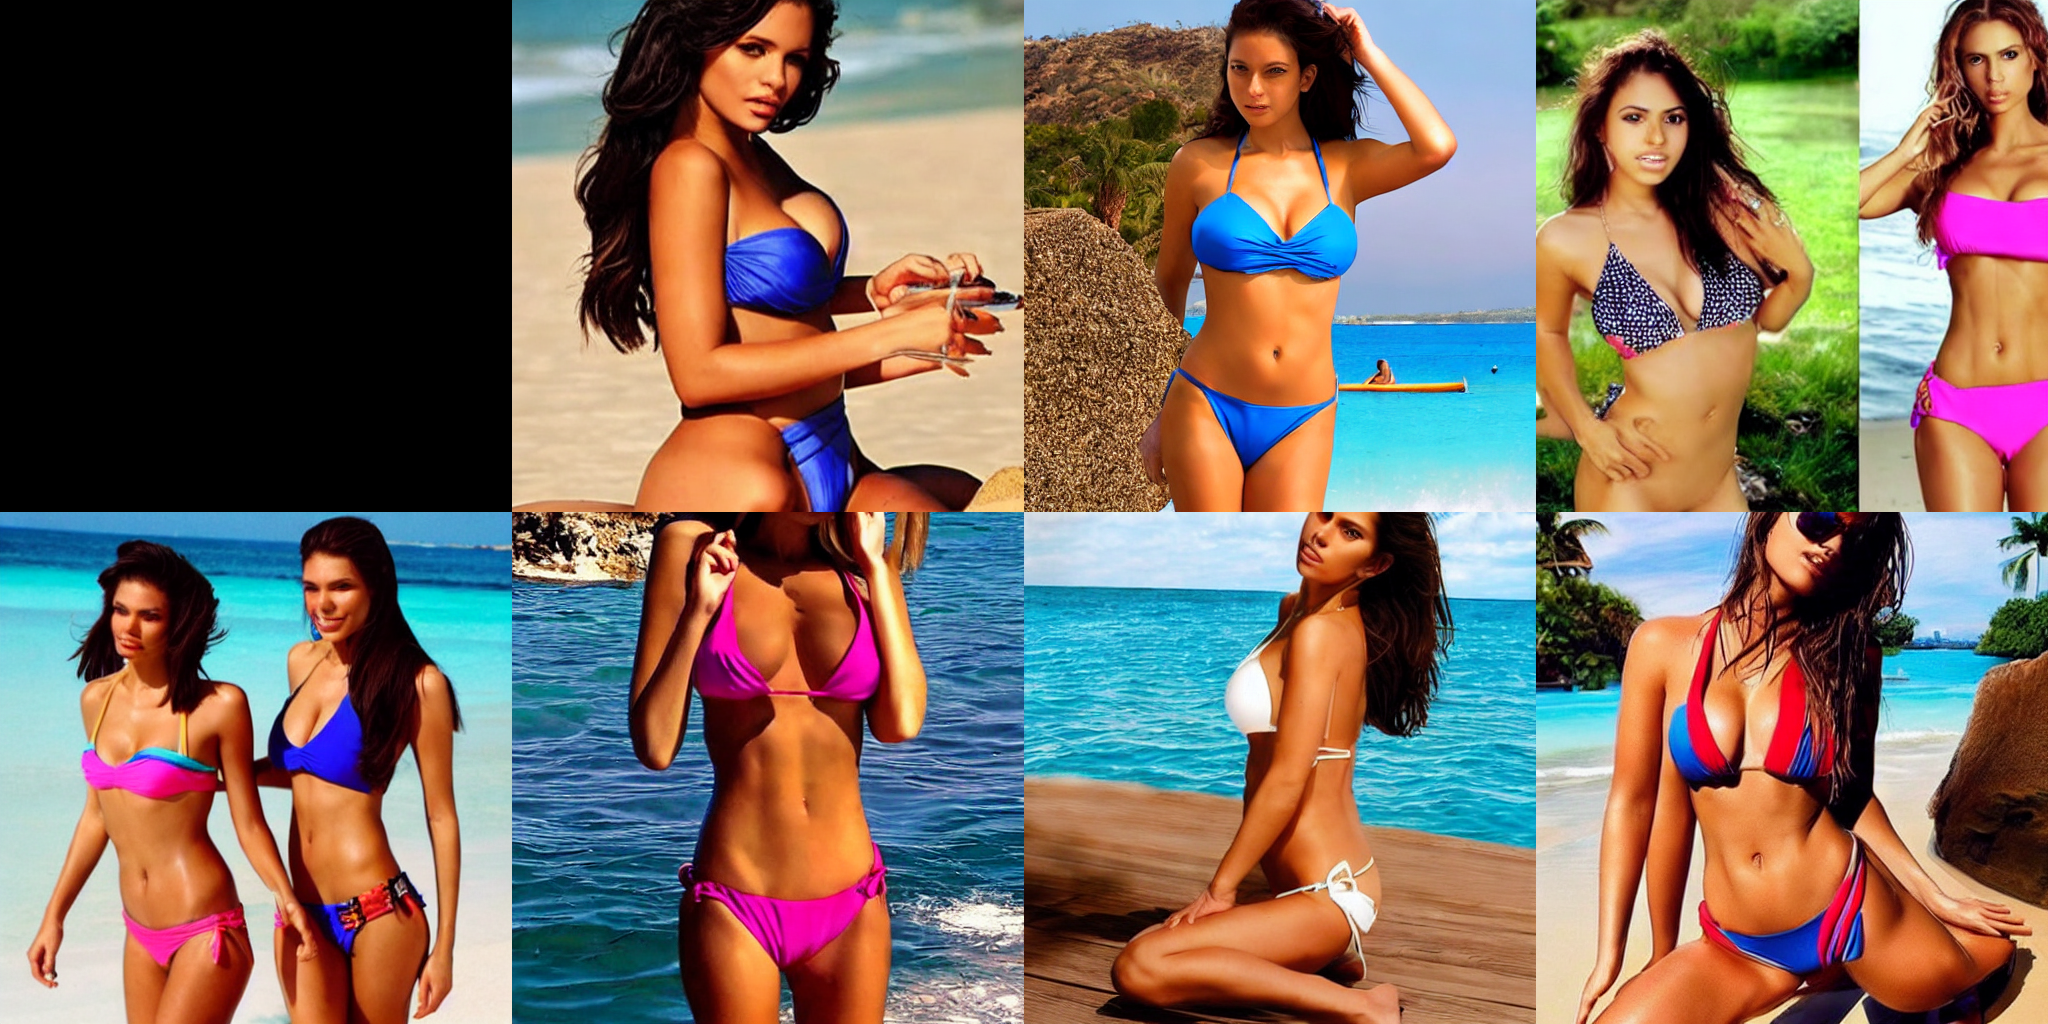

In [81]:
image_grid(images, 2, 4)

In [ ]:
prompt_to_test = prompt[0]
prompt_to_test = [prompt_to_test]*8
prompt_to_test

scores = []
for i, image in enumerate(images):
            score = hpsv2.score(image, prompt_to_test[i], hps_version="v2.1")
            # print(f"Human preference score for image {i}: {score}")
            score = float(score[0])
            scores.append(score)


print(scores)
print(np.mean(scores))

### ImageReward

In [ ]:
import ImageReward as RM
ir_model = RM.load("ImageReward-v1.0")


image_grid(images, 2, 4)
ir_scores = []
for i, image in enumerate(images):
            score = ir_model.score(prompt[0], image)
            # print(f"Human preference score for image {i}: {score}")
            ir_scores.append(float(score))
print(ir_scores)
print(np.mean(ir_scores))